# IBRD World Loans: Anomaly Detection

This notebook identifies unusual loan records that may indicate data issues, fraud risk, or special cases requiring review.
It compares Isolation Forest and Local Outlier Factor (LOF) results and exports a final watchlist for audit follow-up.


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler

candidate_roots = [
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
    Path('/home/rigii/ATA').resolve(),
]
project_root = next((root for root in candidate_roots if (root / 'data' / 'processed' / 'ibrd_clean.csv').exists()), Path.cwd().resolve())
DATA_PATH = project_root / 'data' / 'processed' / 'ibrd_clean.csv'
FIGURES_DIR = project_root / 'reports' / 'figures'
FEATURES_DIR = project_root / 'data' / 'features'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root: {project_root}')
print(f'Data path: {DATA_PATH}')
print(f'Figures dir: {FIGURES_DIR}')
print(f'Features dir: {FEATURES_DIR}')


Project root: /home/rigii/ATA
Data path: /home/rigii/ATA/data/processed/ibrd_clean.csv
Figures dir: /home/rigii/ATA/reports/figures
Features dir: /home/rigii/ATA/data/features


In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df)} loans')
print(df.columns[:10].tolist())

amount_cols = [
    'Original Principal Amount (US$)',
    'Disbursed Amount (US$)',
    'Undisbursed Amount (US$)',
    'Cancelled Amount (US$)',
    'Repaid to IBRD (US$)',
    'Due to IBRD (US$)',
]

for col in amount_cols:
    df[col] = pd.to_numeric(df.get(col, pd.Series(np.nan, index=df.index)), errors='coerce')

if 'interest_rate' not in df.columns:
    df['interest_rate'] = np.nan
else:
    df['interest_rate'] = pd.to_numeric(df['interest_rate'], errors='coerce')

if 'loan_age_years' not in df.columns:
    df['loan_age_years'] = np.nan
else:
    df['loan_age_years'] = pd.to_numeric(df['loan_age_years'], errors='coerce')

if 'repayment_ratio' not in df.columns:
    df['repayment_ratio'] = np.nan
else:
    df['repayment_ratio'] = pd.to_numeric(df['repayment_ratio'], errors='coerce')

df['Loan Number'] = df.get('Loan Number', '').astype(str)
print('Columns present:', [c for c in ['Loan Number', 'Country / Economy', 'Region', 'Loan Status'] if c in df.columns])


Loaded 9518 loans
['End of Period', 'Loan Number', 'Region', 'Country / Economy Code', 'Country / Economy', 'Borrower', 'Guarantor Country / Economy Code', 'Guarantor', 'Loan Type', 'Loan Status']
Columns present: ['Loan Number', 'Country / Economy', 'Region', 'Loan Status']


In [3]:
feature_cols = [
    'Original Principal Amount (US$)',
    'Disbursed Amount (US$)',
    'Undisbursed Amount (US$)',
    'Cancelled Amount (US$)',
    'Repaid to IBRD (US$)',
    'Due to IBRD (US$)',
    'loan_age_years',
    'repayment_ratio',
    'interest_rate',
]

anomaly_df = df.copy()
for col in feature_cols:
    anomaly_df[col] = pd.to_numeric(anomaly_df.get(col, pd.Series(np.nan, index=anomaly_df.index)), errors='coerce')

for col in ['Original Principal Amount (US$)', 'Disbursed Amount (US$)', 'Undisbursed Amount (US$)', 'Cancelled Amount (US$)', 'Repaid to IBRD (US$)', 'Due to IBRD (US$)']:
    anomaly_df[col] = anomaly_df[col].fillna(0)

for col in ['loan_age_years', 'repayment_ratio', 'interest_rate']:
    anomaly_df[col] = anomaly_df[col].fillna(0)

anomaly_df = anomaly_df[anomaly_df['Original Principal Amount (US$)'] > 0].copy()
print(f'Rows retained after dropping zero original amount: {len(anomaly_df)}')
print(anomaly_df[feature_cols].head())


Rows retained after dropping zero original amount: 9204
   Original Principal Amount (US$)  Disbursed Amount (US$)  \
0                      150000000.0            1.379060e+08   
1                      150000000.0            1.358972e+08   
2                      120000000.0            1.185807e+08   
3                      600000000.0            5.980064e+08   
4                      200000000.0            1.889046e+08   

   Undisbursed Amount (US$)  Cancelled Amount (US$)  Repaid to IBRD (US$)  \
0                       0.0             12094000.66           23646955.00   
1                       0.0             14102831.83            6237680.03   
2                       0.0              1419267.45           16402743.76   
3                       0.0              1914958.33           82332293.28   
4                       0.0             11095390.61           13563431.56   

   Due to IBRD (US$)  loan_age_years  repayment_ratio  interest_rate  
0       1.142590e+08        9.522245 

In [4]:
for col in [
    'Original Principal Amount (US$)',
    'Disbursed Amount (US$)',
    'Undisbursed Amount (US$)',
    'Cancelled Amount (US$)',
    'Repaid to IBRD (US$)',
    'Due to IBRD (US$)',
]:
    anomaly_df[col] = np.log1p(anomaly_df[col].clip(lower=0))

scaler = RobustScaler()
X = anomaly_df[feature_cols].copy()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=anomaly_df.index)
print('Scaled feature matrix shape:', X_scaled.shape)


Scaled feature matrix shape: (9204, 9)


In [5]:
iso_model = IsolationForest(contamination=0.03, random_state=42)
anomaly_df['iso_anomaly'] = iso_model.fit_predict(X_scaled)
anomaly_df['iso_score'] = -iso_model.score_samples(X_scaled)

lof_model = LocalOutlierFactor(n_neighbors=20, contamination=0.03, novelty=False)
anomaly_df['lof_anomaly'] = lof_model.fit_predict(X_scaled)
anomaly_df['lof_score'] = -lof_model.negative_outlier_factor_

anomaly_df['agreed_anomaly'] = ((anomaly_df['iso_anomaly'] == -1) & (anomaly_df['lof_anomaly'] == -1)).astype(int)
print('Isolation Forest anomalies:', (anomaly_df['iso_anomaly'] == -1).sum())
print('LOF anomalies:', (anomaly_df['lof_anomaly'] == -1).sum())
print('Agreed anomalies:', anomaly_df['agreed_anomaly'].sum())


Isolation Forest anomalies: 277
LOF anomalies: 277
Agreed anomalies: 74


In [6]:
score_cols = ['iso_score', 'lof_score']
anomaly_df['combined_score'] = anomaly_df[score_cols].mean(axis=1)
top_anomalies = anomaly_df.loc[anomaly_df['agreed_anomaly'] == 1].sort_values('combined_score', ascending=False).head(20).copy()

if top_anomalies.empty:
    top_anomalies = anomaly_df.sort_values('combined_score', ascending=False).head(20).copy()

display_cols = [
    'Loan Number',
    'Country / Economy',
    'Region',
    'Loan Status',
    'Original Principal Amount (US$)',
    'Disbursed Amount (US$)',
    'Undisbursed Amount (US$)',
    'Cancelled Amount (US$)',
    'Repaid to IBRD (US$)',
    'Due to IBRD (US$)',
    'loan_age_years',
    'repayment_ratio',
    'interest_rate',
    'combined_score',
]
print(top_anomalies[display_cols].head(10).to_string(index=False))


Loan Number Country / Economy                        Region Loan Status  Original Principal Amount (US$)  Disbursed Amount (US$)  Undisbursed Amount (US$)  Cancelled Amount (US$)  Repaid to IBRD (US$)  Due to IBRD (US$)  loan_age_years  repayment_ratio  interest_rate  combined_score
  IBRDG2030          Botswana   EASTERN AND SOUTHERN AFRICA   Effective                        19.307177                     0.0                 19.007679               17.955518                   0.0                0.0       16.837782              0.0            0.0        3.321390
  IBRDG2410          Pakistan MID EAST,NORTH AFRICA,AFG,PAK   Effective                        19.855765                     0.0                 18.177016               19.649224                   0.0                0.0       10.193018              0.0            0.0        2.542066
  IBRDG2460         Argentina   LATIN AMERICA AND CARIBBEAN   Effective                        19.989297                     0.0                 19.

In [7]:
region_summary = (
    anomaly_df.groupby('Region', dropna=False)
    .agg(
        anomaly_count=('agreed_anomaly', 'sum'),
        total_loans=('Loan Number', 'count')
    )
    .sort_values('anomaly_count', ascending=False)
)
print('Anomalies by region:\n', region_summary.head(10))

status_summary = (
    anomaly_df.groupby('Loan Status', dropna=False)
    .agg(
        anomaly_count=('agreed_anomaly', 'sum'),
        total_loans=('Loan Number', 'count')
    )
    .sort_values('anomaly_count', ascending=False)
)
print('Anomalies by loan status:\n', status_summary.head(10))


Anomalies by region:
                                anomaly_count  total_loans
Region                                                   
EUROPE AND CENTRAL ASIA                   31         1890
LATIN AMERICA AND CARIBBEAN               17         2877
EAST ASIA AND PACIFIC                      8         1909
EASTERN AND SOUTHERN AFRICA                7          433
WESTERN AND CENTRAL AFRICA                 6          413
SOUTH ASIA                                 3          456
MID EAST,NORTH AFRICA,AFG,PAK              2         1226
Anomalies by loan status:
                      anomaly_count  total_loans
Loan Status                                    
Fully Repaid                    27         6582
Effective                       13           48
Fully Cancelled                 13          202
Disbursing                       7          531
Signed                           7           48
Terminated                       5           41
Repaying                         2         12

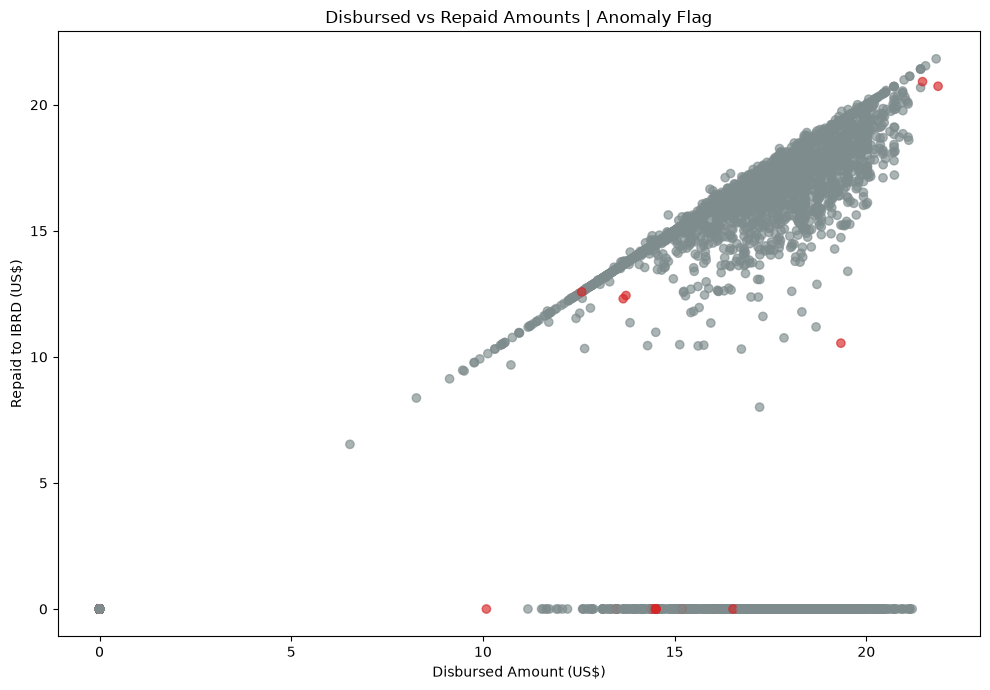

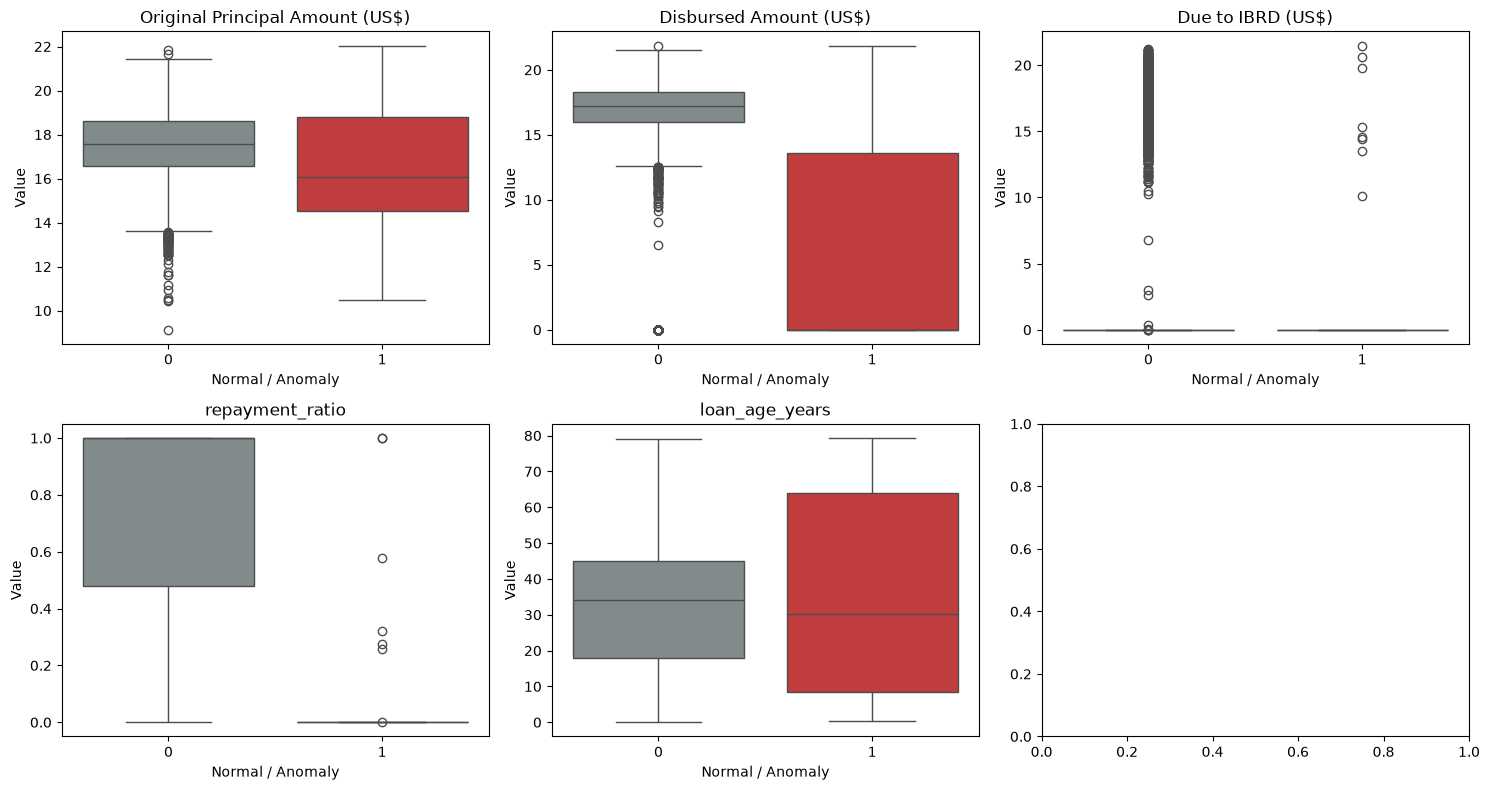

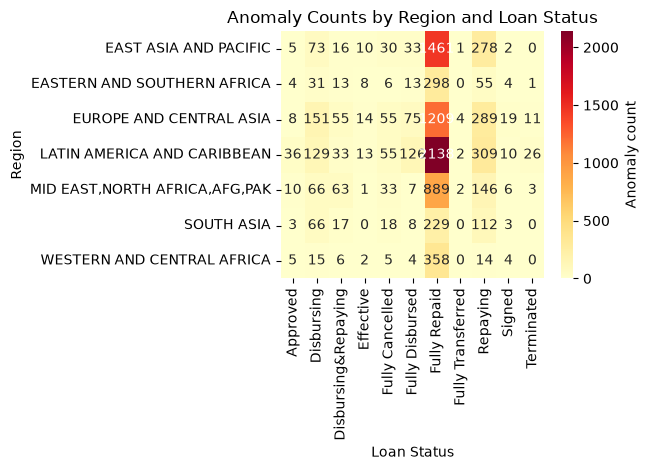

Saved anomaly scatter, boxplots, and heatmap to /home/rigii/ATA/reports/figures


In [8]:
anomaly_df['is_anomaly'] = (anomaly_df['agreed_anomaly'] == 1).astype(int)

scatter = px.scatter(
    anomaly_df,
    x='Disbursed Amount (US$)',
    y='Repaid to IBRD (US$)',
    color='is_anomaly',
    color_continuous_scale=['#cccccc', '#d62728'],
    title='IBRD Loan Disbursed vs Repaid, Highlighting Anomalies',
    hover_data=['Loan Number', 'Country / Economy', 'Region', 'Loan Status']
)
scatter.write_html(str(FIGURES_DIR / 'anomaly_scatter.html'))

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(
    anomaly_df['Disbursed Amount (US$)'],
    anomaly_df['Repaid to IBRD (US$)'],
    c=anomaly_df['is_anomaly'].map({0: '#7f8c8d', 1: '#d62728'}),
    alpha=0.65
)
ax.set_title('Disbursed vs Repaid Amounts | Anomaly Flag')
ax.set_xlabel('Disbursed Amount (US$)')
ax.set_ylabel('Repaid to IBRD (US$)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'anomaly_scatter.png', dpi=200)
plt.show()

box_df = anomaly_df.melt(
    id_vars=['is_anomaly'],
    value_vars=['Original Principal Amount (US$)', 'Disbursed Amount (US$)', 'Due to IBRD (US$)', 'repayment_ratio', 'loan_age_years'],
    var_name='feature',
    value_name='value'
)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, feature in zip(axes, ['Original Principal Amount (US$)', 'Disbursed Amount (US$)', 'Due to IBRD (US$)', 'repayment_ratio', 'loan_age_years']):
    subset = box_df[box_df['feature'] == feature]
    # seaborn will treat 'is_anomaly' values as strings when reading from dataframe
    # ensure palette keys match the categorical values present in the column
    palette_map = {'0': '#7f8c8d', '1': '#d62728'}
    sns.boxplot(data=subset, x='is_anomaly', y='value', ax=ax, palette=palette_map)
    ax.set_title(feature)
    ax.set_xlabel('Normal / Anomaly')
    ax.set_ylabel('Value')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'anomaly_boxplots.png', dpi=200)
plt.show()

region_status = pd.crosstab(anomaly_df['Region'].fillna('Unknown'), anomaly_df['Loan Status'].fillna('Unknown'))
heatmap = sns.heatmap(region_status, cmap='YlOrRd', annot=True, fmt='d', cbar_kws={'label': 'Anomaly count'})
heatmap.set_title('Anomaly Counts by Region and Loan Status')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'anomaly_heatmap.png', dpi=200)
plt.show()
print('Saved anomaly scatter, boxplots, and heatmap to', FIGURES_DIR)


In [38]:
feature_rank_cols = [
    'Original Principal Amount (US$)',
    'Disbursed Amount (US$)',
    'Undisbursed Amount (US$)',
    'Cancelled Amount (US$)',
    'Repaid to IBRD (US$)',
    'Due to IBRD (US$)',
    'loan_age_years',
    'repayment_ratio',
    'interest_rate',
]

watchlist = anomaly_df.loc[anomaly_df['agreed_anomaly'] == 1].copy()
if watchlist.empty:
    watchlist = anomaly_df.sort_values('combined_score', ascending=False).head(100).copy()

watchlist['reason'] = ''
for idx, row in watchlist.iterrows():
    row_values = {
        feature: abs(row[feature]) if pd.notna(row.get(feature)) else 0
        for feature in feature_rank_cols
    }
    largest_feature = max(row_values, key=row_values.get)
    watchlist.at[idx, 'reason'] = largest_feature

watchlist = watchlist[
    [
        'Loan Number',
    'Country / Economy',
    'Region',
    'Loan Status',
    'Original Principal Amount (US$)',
    'Disbursed Amount (US$)',
    'Undisbursed Amount (US$)',
    'Cancelled Amount (US$)',
    'Repaid to IBRD (US$)',
    'Due to IBRD (US$)',
    'loan_age_years',
    'repayment_ratio',
    'interest_rate',
    'reason',
    'combined_score',
    ]
]
watchlist = watchlist.sort_values('combined_score', ascending=False).reset_index(drop=True)
watchlist_path = FEATURES_DIR / 'anomaly_watchlist.csv'
watchlist.to_csv(watchlist_path, index=False)
print(f'Saved anomaly watchlist to {watchlist_path}')
print(watchlist.head(10).to_string(index=False))


Saved anomaly watchlist to /home/rigii/ATA/data/features/anomaly_watchlist.csv
Loan Number Country / Economy                        Region  Loan Status  Original Principal Amount (US$)  Disbursed Amount (US$)  Undisbursed Amount (US$)  Cancelled Amount (US$)  Repaid to IBRD (US$)  Due to IBRD (US$)  loan_age_years  repayment_ratio  interest_rate         reason  combined_score
  IBRDG2570         Argentina   LATIN AMERICA AND CARIBBEAN    Effective                         3.012440                0.000000                  2.928466                3.001757                   0.0                0.0        8.462697              0.0            0.0 loan_age_years        4.242250
  IBRDG2390           Croatia       EUROPE AND CENTRAL ASIA       Signed                         3.013683                0.000000                  2.925983                2.988276                   0.0                0.0       13.177276              0.0            0.0 loan_age_years        4.105563
  IBRDG2030          

## Audit recommendations

- Unusual loans often cluster around extreme amount mismatches such as very high disbursement relative to principal, unusually high cancellation, or repayment-to-principal ratios that do not align with the expected lifecycle.
- Countries or regions with repeated anomalies should be flagged for a deeper review of loan processing controls, project documentation, and internal approvals.
- Any anomaly linked to a material discrepancy in outstanding balances or repayment timing should be escalated for internal audit and potentially a data-quality remediation workflow.
- The watchlist should be reviewed with operations, legal, and finance teams to confirm whether anomalies reflect genuine exceptions, data entry mistakes, or potential fraud indicators.


In [10]:
print('Notebook execution complete. Review the anomaly watchlist, charts, and summary for audit follow-up.')


Notebook execution complete. Review the anomaly watchlist, charts, and summary for audit follow-up.
